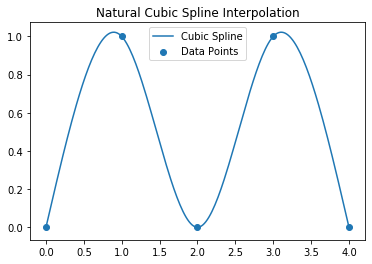

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# data points
x = np.array([0, 1, 2, 3, 4], dtype=float)
y = np.array([0, 1, 0, 1, 0], dtype=float)

# step size
n = len(x)
h = np.zeros(n - 1)

for i in range(n - 1):
    h[i] = x[i+1] - x[i]

# tridiagonal system
A = np.zeros(n - 2)
B = np.zeros(n - 2)
C = np.zeros(n - 2)
D = np.zeros(n - 2)

for i in range(1, n - 1):
    A[i-1] = h[i-1]
    B[i-1] = 2 * (h[i-1] + h[i])
    C[i-1] = h[i]
    
    D[i-1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

# Thomas Algorithm
for i in range(1, n - 2):
    factor = A[i] / B[i-1]
    B[i] = B[i] - factor * C[i-1]
    D[i] = D[i] - factor * D[i-1]

# Back substitution
M = np.zeros(n)  # second derivatives (natural spline => ends = 0)

M[n-2] = D[n-3] / B[n-3]

for i in range(n - 4, -1, -1):
    M[i+1] = (D[i] - C[i] * M[i+2]) / B[i]

# Evaluate spline
def evaluate_spline(x_eval):
    # find interval
    for i in range(n - 1):
        if x_eval >= x[i] and x_eval <= x[i+1]:
            break
    
    hi = x[i+1] - x[i]
    
    term1 = M[i] * (x[i+1] - x_eval)**3 / (6 * hi)
    term2 = M[i+1] * (x_eval - x[i])**3 / (6 * hi)
    term3 = (y[i] - M[i] * hi**2 / 6) * (x[i+1] - x_eval) / hi
    term4 = (y[i+1] - M[i+1] * hi**2 / 6) * (x_eval - x[i]) / hi
    
    return term1 + term2 + term3 + term4

# Generate curve
x_vals = np.linspace(x[0], x[-1], 200)
y_vals = []

for val in x_vals:
    y_vals.append(evaluate_spline(val))

# Plot results
plt.scatter(x, y, label="Data Points")
plt.plot(x_vals, y_vals, label="Cubic Spline")
plt.legend()
plt.title("Natural Cubic Spline Interpolation")
plt.show()